<font color="black"><font size="7"> OpenClassrooms Projet 3 </font>

<font color="grey"> Chargement des modules necessaires </font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# <font color="blue"> Preprocessing des données </font>

## <font color="black"> Chargement du jeu de données</font>

In [159]:
data=pd.read_csv("fr.openfoodfacts.org.products.csv",sep='\t',low_memory=False)
df=data.copy()

In [160]:
df.shape

(320772, 162)

## Nombres et type de variable

In [161]:
df.dtypes.value_counts()

float64    106
object      56
dtype: int64

## Valeurs manquantes

### Identification

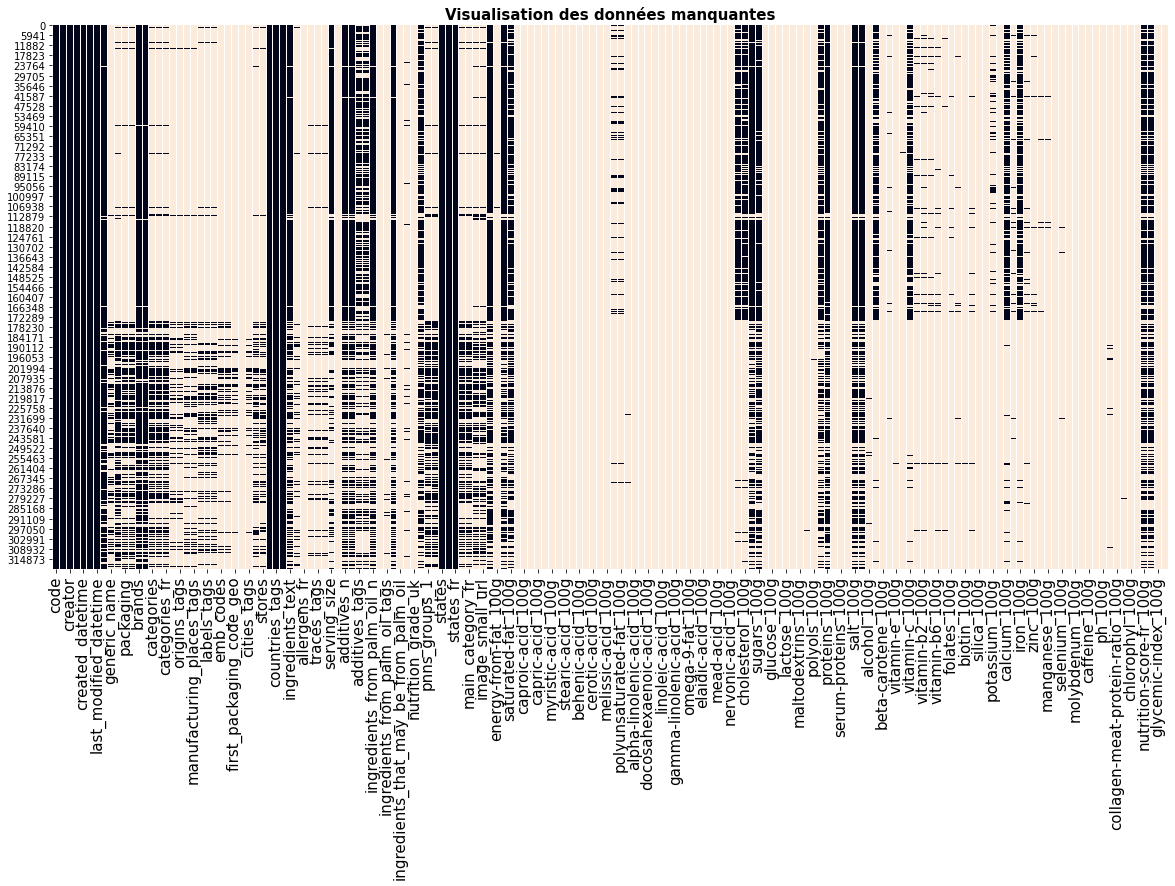

In [162]:
plt.figure(figsize=(20,10))
plt.title("Visualisation des données manquantes",fontweight='bold',fontsize=15)
sns.heatmap(data.isna(), cbar=False)
plt.xticks(fontsize='15')
plt.show()

### Traitement

Pourcentage de valeurs manquantes

In [163]:
pd.options.display.max_rows = 200
(df.isna().sum(axis = 0)/df.shape[0]).sort_values(ascending=False)

water-hardness_100g                           1.000000
nervonic-acid_100g                            1.000000
no_nutriments                                 1.000000
ingredients_from_palm_oil                     1.000000
ingredients_that_may_be_from_palm_oil         1.000000
nutrition_grade_uk                            1.000000
butyric-acid_100g                             1.000000
caproic-acid_100g                             1.000000
lignoceric-acid_100g                          1.000000
cerotic-acid_100g                             1.000000
glycemic-index_100g                           1.000000
elaidic-acid_100g                             1.000000
mead-acid_100g                                1.000000
erucic-acid_100g                              1.000000
melissic-acid_100g                            1.000000
chlorophyl_100g                               1.000000
palmitic-acid_100g                            0.999997
montanic-acid_100g                            0.999997
caprylic-a

Listons les variable ayant plus de 50% de valeurs manquantes

In [164]:
bad_var=df.columns[(df.isna().sum(axis = 0)/df.shape[0]) > 0.5]

In [165]:
bad_var.values

array(['generic_name', 'quantity', 'packaging', 'packaging_tags',
       'categories', 'categories_tags', 'categories_fr', 'origins',
       'origins_tags', 'manufacturing_places',
       'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_fr',
       'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo',
       'cities', 'cities_tags', 'purchase_places', 'stores', 'allergens',
       'allergens_fr', 'traces', 'traces_tags', 'traces_fr',
       'no_nutriments', 'additives_tags', 'additives_fr',
       'ingredients_from_palm_oil', 'ingredients_from_palm_oil_tags',
       'ingredients_that_may_be_from_palm_oil',
       'ingredients_that_may_be_from_palm_oil_tags', 'nutrition_grade_uk',
       'pnns_groups_1', 'pnns_groups_2', 'main_category',
       'main_category_fr', 'image_url', 'image_small_url',
       'energy-from-fat_100g', 'butyric-acid_100g', 'caproic-acid_100g',
       'caprylic-acid_100g', 'capric-acid_100g', 'lauric-acid_100g',
       'myristic-acid_100g', 'palm

supprimons ces colonnes du dataset

In [166]:
df=df.drop(columns=bad_var)

In [167]:
df.shape

(320772, 34)

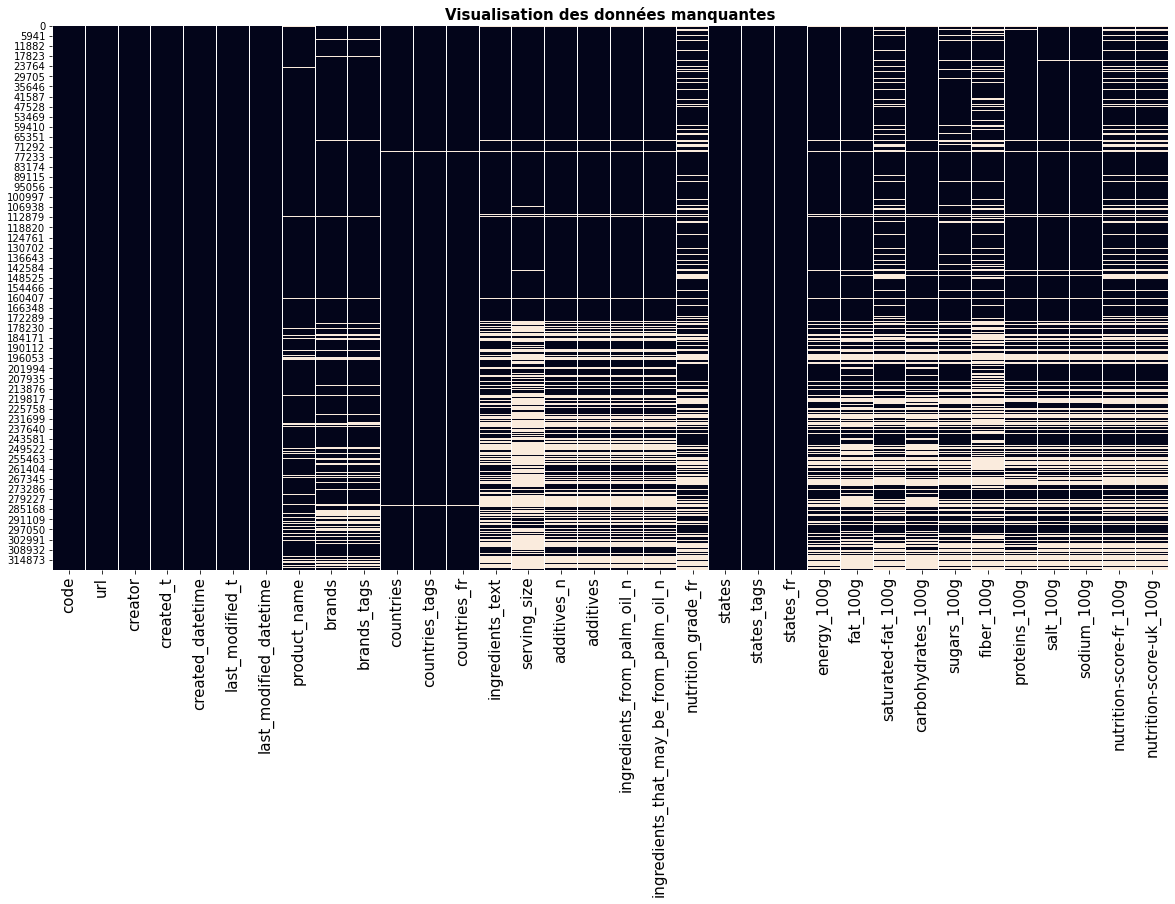

In [168]:
plt.figure(figsize=(20,10))
plt.title("Visualisation des données manquantes",fontweight='bold',fontsize=15)
sns.heatmap(df.isna(), cbar=False)
plt.xticks(fontsize='15')
plt.show()

## Doublons

### Identification

Nous considérons un doublon lorsqu'un produit a le meme 'product_name' et le meme 'brands'

In [169]:
doublons_df=df[df.duplicated(subset=['product_name','brands'])]

In [170]:
doublons_df.shape

(37140, 34)

### Traitement

Enlevons les doublons du dataset

In [171]:
df=df.drop(index=doublons_df.index)

Nombre d'individus sans clé primaire

In [172]:
df[df['product_name'].isna() & df['brands'].isna()]

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
48,0000000027205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sortons cette variable du dataframe

In [173]:
df=df.drop(index=df[df['product_name'].isna() & df['brands'].isna()].index)

## Selection des variables

Supprimons les variables redondantes ou sans interet

In [174]:
df=df.drop(columns=['created_t',
                 'last_modified_t',
                 'url',
                 'brands_tags',
                 'countries',
                 'countries_tags',
                 'states',
                 'states_fr',
                 'states_tags',
                 'creator'])

In [175]:
df.to_csv("openfoodfact_clean.csv",index=False)

In [185]:
df=pd.read_csv("openfoodfact_clean.csv",low_memory=False)

## Changement des types de données

In [186]:
df.created_datetime=pd.to_datetime(df.created_datetime,errors='coerce')
df.last_modified_datetime=pd.to_datetime(df.last_modified_datetime,errors='coerce')

In [187]:
cols = ['code',
        'product_name',
        'brands',
        'countries_fr',
        'ingredients_text',
        'additives',
        'nutrition_grade_fr']
df[cols] = df[cols].astype(pd.StringDtype())

In [188]:
(df.isna().sum(axis = 0)/df.shape[0]).sort_values(ascending=False)

fiber_100g                                 0.347945
serving_size                               0.320818
nutrition-score-uk_100g                    0.280999
nutrition-score-fr_100g                    0.280999
nutrition_grade_fr                         0.280999
saturated-fat_100g                         0.255021
carbohydrates_100g                         0.215259
fat_100g                                   0.214151
sugars_100g                                0.206575
additives                                  0.192789
additives_n                                0.192680
ingredients_from_palm_oil_n                0.192680
ingredients_that_may_be_from_palm_oil_n    0.192680
ingredients_text                           0.192666
sodium_100g                                0.173352
salt_100g                                  0.173214
proteins_100g                              0.159200
energy_100g                                0.155336
brands                                     0.042319
product_name

# Etude Univarié

## Variable quantitative

In [189]:
df.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,228981.000000,228981.000000,228981.000000,2.395730e+05,222891.000000,211299.000000,222577.000000,225040.000000,184943.000000,238477.000000,234502.000000,234463.000000,203931.000000,203931.000000
mean,1.932671,0.019622,0.055987,1.143811e+03,12.676289,5.133070,32.219170,15.894915,2.879181,7.112967,2.062974,0.812327,9.150232,9.046570
std,2.510138,0.140449,0.271883,6.722064e+03,17.379025,8.056049,29.783002,22.312407,13.352206,8.411232,133.728997,52.653588,9.059554,9.190249
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-17.860000,-6.700000,-800.000000,0.000000,0.000000,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,3.850000e+02,0.000000,0.000000,6.000000,1.300000,0.000000,0.700000,0.063500,0.025000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1.103000e+03,5.080000,1.790000,21.000000,5.600000,1.500000,4.840000,0.591820,0.233000,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1.674000e+03,20.000000,7.140000,58.820000,24.000000,3.600000,10.000000,1.384300,0.545000,16.000000,16.000000
max,31.000000,2.000000,6.000000,3.251373e+06,714.290000,550.000000,2916.670000,3520.000000,5380.000000,430.000000,64312.800000,25320.000000,40.000000,40.000000


## Identification et suppression des outliers

### Valeurs impossibles

Suppression des outliers sur les variables _100g

In [190]:
df_test=df.copy()

In [191]:
for col in [
            'fat_100g',
            'saturated-fat_100g',
            'carbohydrates_100g',
            'sugars_100g',
            'fiber_100g',
            'proteins_100g',
            'salt_100g',
            'sodium_100g']:
    
    print(f'suppression de {df_test[df_test[col]>100].shape[0]} valeurs de la colonne {col}')
    df_test=df_test.drop(index=df_test[df_test[col]>100].index)
    

suppression de 4 valeurs de la colonne fat_100g
suppression de 2 valeurs de la colonne saturated-fat_100g
suppression de 15 valeurs de la colonne carbohydrates_100g
suppression de 0 valeurs de la colonne sugars_100g
suppression de 2 valeurs de la colonne fiber_100g
suppression de 0 valeurs de la colonne proteins_100g
suppression de 142 valeurs de la colonne salt_100g
suppression de 0 valeurs de la colonne sodium_100g


In [192]:
df_test.shape

(283466, 24)

In [193]:
df_test.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,228824.000000,228824.000000,228824.000000,2.394120e+05,222735.000000,211228.000000,222419.000000,224964.000000,184881.000000,238324.00000,234342.000000,234303.000000,203868.000000,203868.000000
mean,1.933473,0.019631,0.056017,1.142716e+03,12.677086,5.128892,32.212824,15.875426,2.847140,7.11439,1.602403,0.630971,9.148361,9.044622
std,2.510251,0.140481,0.271958,6.703969e+03,17.298305,7.944994,29.136725,21.045057,4.615241,8.36731,6.253981,2.462380,9.059261,9.189947
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-17.860000,-6.700000,-800.00000,0.000000,0.000000,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,3.850000e+02,0.000000,0.000000,6.000000,1.300000,0.000000,0.71000,0.063500,0.025000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1.105000e+03,5.100000,1.790000,21.000000,5.600000,1.500000,4.85000,0.591820,0.233000,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1.674000e+03,20.000000,7.140000,58.820000,24.000000,3.600000,10.00000,1.381760,0.544000,16.000000,16.000000
max,31.000000,2.000000,6.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,39.370079,40.000000,40.000000


### Suppression des outliers sur la regle des quantiles

Fonction identifiant et supprimant les outliers

In [206]:
#fonction qui retourne le dataframe sans les outliers basés sur la régle des quantiles
def remove_outliers_quantile(data,col):
    Quant=data[col].quantile([0.25,0.5,0.75]).values #Calcul des quantiles
    print(Quant)
    if int(Quant[0])==0:
        print(f'pas de traitement car Q1=0')
        return data
    else:
        n=data[(data[col]>=(Quant[1]+1.5*Quant[2]))].shape[0] # nombre d'outliers
        print(f'traitement de la colonne {col} suppression de {n} outliers en dehors de l\'interval [0,{Quant[1]+1.5*Quant[2]}]')
        return data[(data[col]>=0) & (data[col]<Quant[1]+1.5*Quant[2])]


Test de la fonction

In [195]:
T =pd.DataFrame([1,2,1,2,1,2,8,2,2,1,2,9,2,1,2,-45,+52],columns=['value'])
T.shape

(17, 1)

In [196]:
T=remove_outliers(T,'value')

[1. 2. 2.]
traitement de la colonne value suppression de 3 outliers en dehors de l'interval [0,5.0]


In [197]:
T.shape

(13, 1)

## Applications au données

In [205]:
for col in ['energy_100g','sodium_100g']:
    df_test=remove_outliers(df_test,col)

[ 385. 1100. 1674.]
traitement de la colonne energy_100g suppression de 5 outliers en dehors de l'interval [0,3611.0]
[0.027 0.236 0.548]
pas de traitement car Q3=0


In [199]:
df_test.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,214046.000000,214046.000000,214046.000000,238407.000000,220849.000000,209902.000000,220988.000000,223978.000000,183991.000000,236914.000000,232774.000000,232747.000000,203018.000000,203018.000000
mean,2.002345,0.019617,0.056002,1115.677952,12.358312,5.035353,32.314935,15.897967,2.851850,7.134910,1.603362,0.631317,9.131717,9.018811
std,2.527316,0.140422,0.270413,776.137516,16.568321,7.604681,29.120236,21.038094,4.613215,8.361115,6.231695,2.453548,9.058217,9.183553
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-17.860000,-6.700000,-800.000000,0.000000,0.000000,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,385.000000,0.000000,0.000000,6.200000,1.320000,0.000000,0.770000,0.068580,0.027000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1100.000000,5.000000,1.790000,21.200000,5.650000,1.500000,4.900000,0.599440,0.236000,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1674.000000,20.000000,7.140000,58.900000,24.000000,3.600000,10.080000,1.391920,0.548000,16.000000,16.000000
max,31.000000,2.000000,6.000000,3615.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,39.370079,40.000000,37.000000


## Variable additive_n

<AxesSubplot:xlabel='additives_n'>

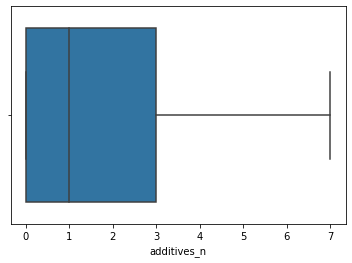

In [212]:
sns.boxplot(x=df_test['additives_n'],showfliers=False)

## Variable 'brands'

In [ ]:
df.brands.isna().sum()

In [ ]:
df.brands.value_counts()

In [ ]:
df_red=df[df.brands.isin(df.brands.value_counts()[0:15].index)]

In [ ]:
sns.displot(df_red,x=df_red.index)

## Variable energy_100g  

In [ ]:
df.energy_100g.describe()

## Outliers

Basé sur les quantiles, on a une borne supérieur à 3654 

In [ ]:
df[df.energy_100g>3654].describe()

# Hypothèse 2: nous nous interessons a l'huile de palme